In [2]:
import os
import platform
from datetime import datetime

os_info = f"{platform.system()} {platform.release()}"
timestamp = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

print(f"Current OS: {os_info}")
print(f"Log Timestamp: {timestamp}")

Current OS: Linux 6.17.0-22-generic
Log Timestamp: 17-03-2026 20:23:26


# **Experiment 5: Data Analytics II**
1. Implement logistic regression using Python/R to perform classification on
Social_Network_Ads.csv dataset.
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

dataset_path = os.path.join("datasets", "Social_Network_Ads.csv")
df = pd.read_csv(dataset_path)

print(f"Dataset Shape: {df.shape}")
print(df.head())


Dataset Shape: (400, 5)
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


### Data Preprocessing
We select relevant features (Age, EstimatedSalary) and perform feature scaling. 
Scaling is a critical booster for Logistic Regression to ensure convergence.

In [ ]:
# X = Age, EstimatedSalary | y = Purchased
X = df.iloc[:, [2, 3]].values
y = df.iloc[:, 4].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


### Model Training
Initializing the Logistic Regression engine to perform binary classification.

In [ ]:
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)


### Confusion Matrix & Performance Metrics
Breaking down the subtasks of classification:
- **TP (True Positive):** Correctly predicted purchase.
- **TN (True Negative):** Correctly predicted no purchase.
- **FP (False Positive):** Incorrectly predicted purchase (Type I Error).
- **FN (False Negative):** Incorrectly predicted no purchase (Type II Error).

--- Confusion Matrix ---
[[65  3]
 [ 8 24]]

TP: 24 | FP: 3 | TN: 65 | FN: 8
Accuracy: 0.89
Error Rate: 0.11
Precision: 0.89
Recall: 0.75


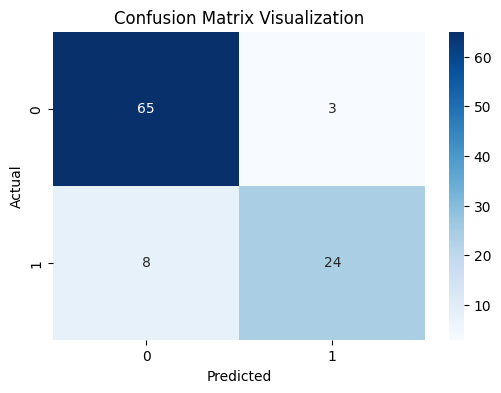

In [4]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"--- Confusion Matrix ---")
print(cm)
print(f"\nTP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Visualization')
plt.show()
